In [18]:
import pandas as pd
df=pd.DataFrame({
    'Marks':[80,85,0,90],
    'Attendance':[75,80,0,85],
    'Grade':['B','A','F','A']
})
print(df)
result=df.sort_values(by='Marks',ascending=False)
print(result)

   Marks  Attendance Grade
0     80          75     B
1     85          80     A
2      0           0     F
3     90          85     A
   Marks  Attendance Grade
3     90          85     A
1     85          80     A
0     80          75     B
2      0           0     F


In [3]:
help(df.sort_values)

Help on method sort_values in module pandas.core.frame:

sort_values(by: 'IndexLabel', *, axis: 'Axis' = 0, ascending: 'bool | list[bool] | tuple[bool, ...]' = True, inplace: 'bool' = False, kind: 'SortKind' = 'quicksort', na_position: 'str' = 'last', ignore_index: 'bool' = False, key: 'ValueKeyFunc | None' = None) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Sort by the values along either axis.

    Parameters
    ----------
    by : str or list of str
        Name or list of names to sort by.

        - if `axis` is 0 or `'index'` then `by` may contain index
          levels and/or column labels.
        - if `axis` is 1 or `'columns'` then `by` may contain column
          levels and/or index labels.
    axis : "{0 or 'index', 1 or 'columns'}", default 0
         Axis to be sorted.
    ascending : bool or list of bool, default True
         Sort ascending vs. descending. Specify list for multiple sort
         orders.  If this is a list of bools, must ma

In [16]:
import pandas as pd
df=pd.DataFrame({
    'Marks':[80,85,0,90],
    'Attendance':[75,80,0,85],
    'Grade':[45,67,89,90]
},index=["AKS","ZPB","ZKG","KGR"])
print(df)
print("-----------------------------")
result=df.sort_values(by="AKS",axis=1)
print(result)

     Marks  Attendance  Grade
AKS     80          75     45
ZPB     85          80     67
ZKG      0           0     89
KGR     90          85     90
-----------------------------
     Marks  Attendance  Grade
AKS     80          75     45
KGR     90          85     90
ZKG      0           0     89
ZPB     85          80     67


In [17]:
df[sorted(df.columns)]

,Attendance,Grade,Marks
AKS,75,45,80
ZPB,80,67,85
ZKG,0,89,0
KGR,85,90,90


In [43]:
import pandas as pd
df1=pd.DataFrame({'C':[1,2],'B':[3,4]})
df2=pd.DataFrame({'A':[5,6],'D':[7,8]})
print(df1)
print(df2)
print()
result=pd.concat([df1,df2],ignore_index=True,sort=True,axis=1)
print(result)

   C  B
0  1  3
1  2  4
   A  D
0  5  7
1  6  8

   0  1  2  3
0  1  3  5  7
1  2  4  6  8


In [42]:
help(pd.concat)

Help on function concat in module pandas.core.reshape.concat:

concat(objs: 'Iterable[Series | DataFrame] | Mapping[HashableT, Series | DataFrame]', *, axis: 'Axis' = 0, join: 'str' = 'outer', ignore_index: 'bool' = False, keys: 'Iterable[Hashable] | None' = None, levels=None, names: 'list[HashableT] | None' = None, verify_integrity: 'bool' = False, sort: 'bool' = False, copy: 'bool | None' = None) -> 'DataFrame | Series'
    Concatenate pandas objects along a particular axis.

    Allows optional set logic along the other axes.

    Can also add a layer of hierarchical indexing on the concatenation axis,
    which may be useful if the labels are the same (or overlapping) on
    the passed axis number.

    Parameters
    ----------
    objs : a sequence or mapping of Series or DataFrame objects
        If a mapping is passed, the sorted keys will be used as the `keys`
        argument, unless it is passed, in which case the values will be
        selected (see below). Any None objects

In [56]:
import pandas as pd
employees=pd.DataFrame({
    'empid':[1,2,3,4],
    'name':['A','B','C','D'],
    'dept_id':[10,20,10,30]
})
departments=pd.DataFrame({
    'dept_id':[10,20,40],
    'dept_name':['HR','IT','Finance']
})
pd.merge(employees,departments,on='dept_id',how='outer')

,empid,name,dept_id,dept_name
0,1.0,A,10,HR
1,3.0,C,10,HR
2,2.0,B,20,IT
3,4.0,D,30,NaN
4,NaN,NaN,40,Finance


In [57]:
import pandas as pd
employees=pd.DataFrame({
    'empid':[1,2,3,4],
    'name':['A','B','C','D'],
    'dept_id':[10,20,10,30]
})
departments=pd.DataFrame({
    'dept_id':[10,20,40],
    'dept_name':['HR','IT','Finance']
})
pd.merge(employees,departments,how='cross')

,empid,name,dept_id_x,dept_id_y,dept_name
0,1,A,10,10,HR
1,1,A,10,20,IT
2,1,A,10,40,Finance
3,2,B,20,10,HR
4,2,B,20,20,IT
5,2,B,20,40,Finance
6,3,C,10,10,HR
7,3,C,10,20,IT
8,3,C,10,40,Finance
9,4,D,30,10,HR


In [58]:
import pandas as pd
employees=pd.DataFrame({
    'empid':[1,2,3,4],
    'name':['A','B','C','D'],
    'dept_id':[10,20,10,30]
})
departments=pd.DataFrame({
    'de_id':[10,20,40],
    'dept_name':['HR','IT','Finance']
})
pd.merge(employees,departments,left_on='dept_id',right_on='de_id')

,empid,name,dept_id,de_id,dept_name
0,1,A,10,10,HR
1,2,B,20,20,IT
2,3,C,10,10,HR


In [69]:
import pandas as pd
employees=pd.DataFrame({
    'empid':[1,2,3,4],
    'name':['A','B','C','D'],
    'dept_id':[10,20,10,30]
})
departments=pd.DataFrame({
    'de_id':[10,20,40],
    'dept_name':['HR','IT','Finance']
})
pd.merge(employees,departments,right_index=True,left_on="dept_id",how="outer")

,empid,name,dept_id,de_id,dept_name
NaN,NaN,NaN,0,10.0,HR
NaN,NaN,NaN,1,20.0,IT
NaN,NaN,NaN,2,40.0,Finance
0.0,1.0,A,10,NaN,NaN
2.0,3.0,C,10,NaN,NaN
1.0,2.0,B,20,NaN,NaN
3.0,4.0,D,30,NaN,NaN


In [74]:
import pandas as pd
employees=pd.DataFrame({
    'empid':[1,2,3,4],
    'dept_name':['A','B','C','D'],
    'dept_id':[10,20,10,30]
})
departments=pd.DataFrame({
    'dept_id':[10,20,40],
    'dept_name':['HR','IT','Finance']
})
pd.merge(employees,departments,on='dept_id',suffixes=['_emp','_dept'])

,empid,dept_name_emp,dept_id,dept_name_dept
0,1,A,10,HR
1,2,B,20,IT
2,3,C,10,HR


In [92]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
result=df.groupby('Department')[["Experience","Salary"]].median()
result

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


,Experience,Salary
Department,,
Finance,5.0,70000.0
HR,1.5,46500.0
IT,3.0,55000.0


In [93]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
result=df.groupby('Department')[["Experience","Salary"]].mean()
result

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


,Experience,Salary
Department,,
Finance,5.0,70000.0
HR,1.5,46500.0
IT,3.0,55000.0


In [76]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
df.groupby(['Department','Employee']).sum()

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


Salary  Experience
Department Employee                    
Finance    E          70000           5
HR         C          45000           1
           D          48000           2
IT         A          50000           2
           B          60000           3
           F          55000           4

In [94]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
result=df.groupby('Department')[["Experience","Salary"]].describe()
result

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


Experience                                           Salary  \
                count mean       std  min   25%  50%   75%  max  count   
Department                                                               
Finance           1.0  5.0       NaN  5.0  5.00  5.0  5.00  5.0    1.0   
HR                2.0  1.5  0.707107  1.0  1.25  1.5  1.75  2.0    2.0   
IT                3.0  3.0  1.000000  2.0  2.50  3.0  3.50  4.0    3.0   

                                                                               
               mean          std      min      25%      50%      75%      max  
Department                                                                     
Finance     70000.0          NaN  70000.0  70000.0  70000.0  70000.0  70000.0  
HR          46500.0  2121.320344  45000.0  45750.0  46500.0  47250.0  48000.0  
IT          55000.0  5000.000000  50000.0  52500.0  55000.0  57500.0  60000.0

In [95]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
result=df.groupby('Department')[["Experience","Salary"]].agg(["min","median"])
result

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


Experience        Salary         
                  min median    min   median
Department                                  
Finance             5    5.0  70000  70000.0
HR                  1    1.5  45000  46500.0
IT                  2    3.0  50000  55000.0

In [96]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
result=df.groupby('Department')[["Experience","Salary"]].nth[0]
result

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


,Experience,Salary
0,2,50000
2,1,45000
4,5,70000


In [97]:
import pandas as pd
data={
    'Department':['IT','IT','HR','HR','Finance','IT'],
    'Employee':['A','B','C','D','E','F'],
    'Salary':[50000,60000,45000,48000,70000,55000],
    'Experience':[2,3,1,2,5,4]
}
df=pd.DataFrame(data)
print(df)
result=df.groupby('Department')[["Experience","Salary"]].sample()
result

  Department Employee  Salary  Experience
0         IT        A   50000           2
1         IT        B   60000           3
2         HR        C   45000           1
3         HR        D   48000           2
4    Finance        E   70000           5
5         IT        F   55000           4


,Experience,Salary
4,5,70000
2,1,45000
1,3,60000


In [100]:
result=df.groupby('Department')[["Experience","Salary"]].count()
result

,Experience,Salary
Department,,
Finance,1,1
HR,2,2
IT,3,3


In [101]:
result=df.groupby('Department')[["Experience","Salary"]].size()
result

Department
Finance    1
HR         2
IT         3
dtype: int64

In [102]:
result=df.groupby('Department')[["Experience","Salary"]].apply(lambda x:x.max())
result

,Experience,Salary
Department,,
Finance,5,70000
HR,2,48000
IT,4,60000


In [103]:
result=df.groupby('Department')
result.groups

{'Finance': [4], 'HR': [2, 3], 'IT': [0, 1, 5]}

In [109]:
result=df.groupby('Department',as_index=False,sort=False).nunique()
result

,Department,Employee,Salary,Experience
0,IT,3,3,3
1,HR,2,2,2
2,Finance,1,1,1


In [117]:
def findoutliers(ds,col):
    Q1=ds[col].quantile(0.25)
    Q3=ds[col].quantile(0.75)
    IQR=Q3-Q1
    low_val=Q1-1.5*IQR
    high_val=Q3+1.5*IQR
    ds=ds.loc[(ds[col]<low_val)|(ds[col]>high_val)]
    return ds

In [111]:
import pandas as pd
df=pd.read_csv("auto-mpg.csv")

In [115]:
findoutliers(df,"acceleration")

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl
11,14.0,8,340.0,160,3609,8.0,70,1,plymouth 'cuda 340
59,23.0,4,97.0,54,2254,23.5,72,2,volkswagen type 3
299,27.2,4,141.0,71,3190,24.8,79,2,peugeot 504
326,43.4,4,90.0,48,2335,23.7,80,2,vw dasher (diesel)
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup


In [118]:
def find_Inliers(ds,col):
    Q1=ds[col].quantile(0.25)
    Q3=ds[col].quantile(0.75)
    IQR=Q3-Q1
    low_val=Q1-1.5*IQR
    high_val=Q3+1.5*IQR
    ds=ds.loc[(ds[col]>low_val)&(ds[col]<high_val)]
    return ds

In [121]:
find_Inliers(df,"mpg")

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


<Axes: >

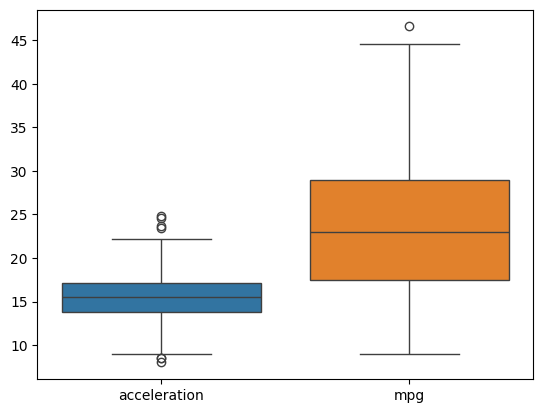

In [132]:
import seaborn as sns
sns.boxplot(df[['acceleration','mpg']])

In [128]:
help(sns.boxplot)

Help on function boxplot in module seaborn.categorical:

boxplot(data=None, *, x=None, y=None, hue=None, order=None, hue_order=None, orient=None, color=None, palette=None, saturation=0.75, fill=True, dodge='auto', width=0.8, gap=0, whis=1.5, linecolor='auto', linewidth=None, fliersize=None, hue_norm=None, native_scale=False, log_scale=None, formatter=None, legend='auto', ax=None, **kwargs)
    Draw a box plot to show distributions with respect to categories.

    A box plot (or box-and-whisker plot) shows the distribution of quantitative
    data in a way that facilitates comparisons between variables or across
    levels of a categorical variable. The box shows the quartiles of the
    dataset while the whiskers extend to show the rest of the distribution,
    except for points that are determined to be "outliers" using a method
    that is a function of the inter-quartile range.

    See the :ref:`tutorial <categorical_tutorial>` for more information.

    .. note::
        By defaul